# Regresión con red neuronal (TensorFlow / Keras)

Predicción de la nota (`grades`) de un estudiante a partir de los features del dataset `Gaming_Academic_Performance.csv`.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

np.random.seed(42)
tf.random.set_seed(42)

## 1. Carga y exploración

In [13]:
df = pd.read_csv("Gaming_Academic_Performance.csv")
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   str    
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   str    
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   str    
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), str(3)
memory usage: 875.1 KB


In [15]:
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


## 2. Preprocesamiento

- Se descarta `student_id` (no aporta señal).
- Las columnas categóricas (`gender`, `gaming_genre`, `stress_level`) se codifican con one-hot.
- Split 80/20 y escalado con `StandardScaler` ajustado solo con el train.

In [16]:
data = df.drop(columns=["student_id"]).copy()

y = data["grades"].astype(float).values
X = data.drop(columns=["grades"])

X = pd.get_dummies(X, columns=["gender", "gaming_genre", "stress_level"], drop_first=True)
X = X.astype(float)

print("Features:", X.shape[1])
X.head()

Features: 15


,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,gender_Male,gender_Other,gaming_genre_FPS,gaming_genre_RPG,stress_level_Low,stress_level_Medium
0,22.0,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,1.0,0.0,1.0,0.0,1.0,0.0
1,19.0,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,1.0,0.0,0.0,0.0,0.0,1.0
2,23.0,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,0.0,0.0,0.0,0.0,0.0,0.0
3,20.0,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,0.0,0.0,0.0,1.0,1.0,0.0
4,22.0,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,0.0,0.0,1.0,0.0,1.0,0.0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (6400, 15)  Test: (1600, 15)


## 3. Modelo Keras (Sequential)

In [18]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="linear"),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - loss: 3354.3433 - mae: 52.6788 - val_loss: 782.4813 - val_mae: 23.6577
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - loss: 411.0624 - mae: 16.2540 - val_loss: 170.5046 - val_mae: 10.5396
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - loss: 242.3394 - mae: 12.3922 - val_loss: 112.2948 - val_mae: 8.5109
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 210.6277 - mae: 11.4993 - val_loss: 89.7702 - val_mae: 7.5929
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - loss: 189.4543 - mae: 10.7864 - val_loss: 77.8786 - val_mae: 7.0529
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - loss: 170.7321 - mae: 10.3193 - val_loss: 74.3840 - val_mae: 6.9146
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - loss: 170.6825 - mae: 10.2996 - val_loss: 68.6900 - val_mae: 6.6337
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 173.5094 - mae: 10.4108 - val_loss: 63.0230 - val_mae: 6.3514
Ep

## 5. Curvas de entrenamiento

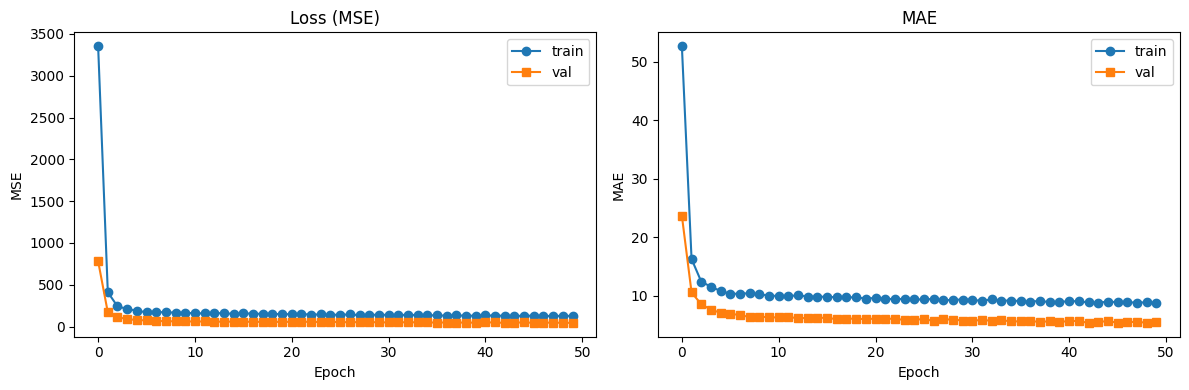

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], "o-", label="train")
axes[0].plot(history.history["val_loss"], "s-", label="val")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history.history["mae"], "o-", label="train")
axes[1].plot(history.history["val_mae"], "s-", label="val")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluación en test

In [21]:
test_mse, test_mae = model.evaluate(X_test, y_test, verbose=0)
y_pred = model.predict(X_test, verbose=0).ravel()
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R^2: {r2:.4f}")

Test MSE: 48.8664
Test MAE: 5.4572
Test R^2: 0.9025


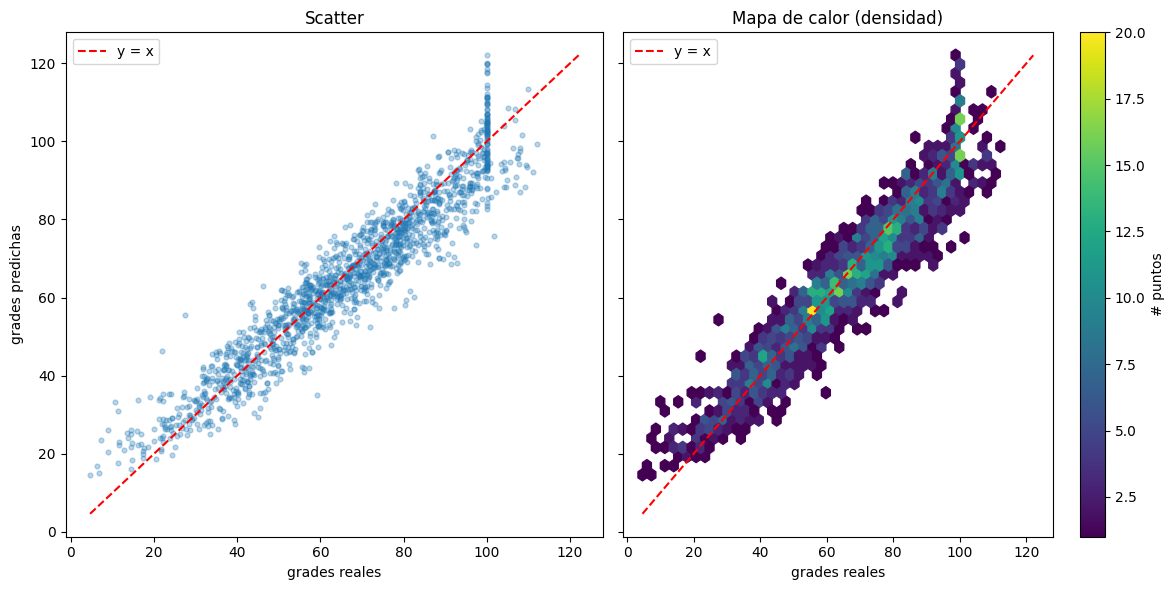

In [22]:
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

axes[0].scatter(y_test, y_pred, alpha=0.3, s=12)
axes[0].plot(lims, lims, "r--", label="y = x")
axes[0].set_xlabel("grades reales")
axes[0].set_ylabel("grades predichas")
axes[0].set_title("Scatter")
axes[0].legend()

hb = axes[1].hexbin(y_test, y_pred, gridsize=40, cmap="viridis", mincnt=1)
axes[1].plot(lims, lims, "r--", label="y = x")
axes[1].set_xlabel("grades reales")
axes[1].set_title("Mapa de calor (densidad)")
axes[1].legend()
fig.colorbar(hb, ax=axes[1], label="# puntos")

plt.tight_layout()
plt.show()


## 7. Conclusiones

- El modelo entrega MAE/MSE/R² resumidos arriba; el scatter permite ver visualmente la calidad de las predicciones respecto a la diagonal `y = x`.
- Mejoras posibles: más capas o neuronas, regularización L2, `EarlyStopping` sobre `val_loss`, búsqueda de hiperparámetros (learning rate, batch size) y comparación contra una regresión lineal como baseline.